<a href="https://colab.research.google.com/github/SeranomTheGreat/Project-Astra/blob/main/ProjectAstra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 T4 GPU detected! Pipeline will run with hardware acceleration.

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loading '/content/drive/MyDrive/Google AI Studio/Data.csv'...
Feature selection: kept 33 relevant features.

Running optimized hyperparameter search (50 trials)...

Training final optimized ensemble...

Test Accuracy: 0.8657
                precision    recall  f1-score   support

     CANDIDATE       0.72      0.64      0.68       396
     CONFIRMED       0.90      0.92      0.91       549
FALSE POSITIVE       0.90      0.93      0.91       968

      accuracy                           0.87      1913
     macro avg       0.84      0.83      0.83      1913
  weighted avg       0.86      0.87      0.86      1913



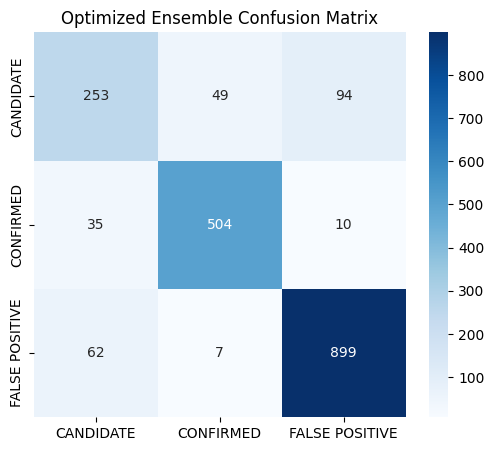

In [ ]:
# ==========================================
# 0. INSTALL REQUIRED PACKAGES
# ==========================================
!pip install catboost optuna lightgbm -q

# ==========================================
# 1. IMPORT LIBRARIES & HARDWARE CHECK
# ==========================================
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import VotingClassifier

# Import state-of-the-art tabular classifiers
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna

# Disable verbose optuna outputs
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Validate GPU availability
device_name = "cuda" if torch.cuda.is_available() else "cpu"
if device_name == "cuda":
    print("🚀 T4 GPU detected! Pipeline will run with hardware acceleration.")
    xgb_gpu_args = {'tree_method': 'hist', 'device': 'cuda'}
    cat_gpu_args = {'task_type': 'GPU', 'verbose': 0}
else:
    print("⚠️ GPU not detected. Defaulting to CPU execution.")
    xgb_gpu_args = {'tree_method': 'hist'}
    cat_gpu_args = {'verbose': 0}

# ==========================================
# 2. CONFIGURABLE SETTINGS
# ==========================================
EXCLUDE_VETTING_FLAGS = True

# ==========================================
# 3. MOUNT GOOGLE DRIVE & LOAD DATASET
# ==========================================
from google.colab import drive
print("\nMounting Google Drive...")
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Google AI Studio/Data.csv"
if not os.path.exists(file_path):
    file_path = "/content/drive/MyDrive/DataChallenge/Data.csv"

print(f"\nLoading '{file_path}'...")
try:
    df = pd.read_csv(file_path, comment='#')
except Exception:
    df = pd.read_csv(file_path)

df = df.dropna(subset=['koi_disposition'])

# ==========================================
# 4. DATA CLEANING & LEAKAGE FILTER
# ==========================================
leakage_and_id_cols = ['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_score', 'koi_pdisposition']
cols_to_drop = [col for col in leakage_and_id_cols if col in df.columns]

if EXCLUDE_VETTING_FLAGS:
    flag_cols = [col for col in df.columns if 'flag' in col]
    cols_to_drop.extend(flag_cols)

df_cleaned = df.drop(columns=cols_to_drop)

# ==========================================
# 5. FEATURE ENGINEERING
# ==========================================
def engineer_features(data):
    X = data.copy()
    if 'koi_prad' in X.columns and 'koi_srad' in X.columns:
        X['radius_ratio'] = (X['koi_prad'] * 0.00915) / (X['koi_srad'] + 1e-5)
    if 'koi_duration' in X.columns and 'koi_period' in X.columns:
        X['transit_duty_cycle'] = (X['koi_duration'] / 24.0) / (X['koi_period'] + 1e-5)
    return X

df_engineered = engineer_features(df_cleaned)
X = df_engineered.drop(columns=['koi_disposition'])
y = df_engineered['koi_disposition']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

# ==========================================
# 6. PREPROCESSING & FEATURE SELECTION
# ==========================================
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Drop empty columns
X_train = X_train.dropna(axis=1, how='all')
X_test = X_test[X_train.columns]

# Impute numerical features
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
imputer = SimpleImputer(strategy='median')
if num_cols:
    X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
    X_test[num_cols] = imputer.transform(X_test[num_cols])

# Handle Categorical Columns carefully
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
cols_to_encode = [c for c in cat_cols if X_train[c].nunique() <= 10]
cols_to_drop_cat = [c for c in cat_cols if X_train[c].nunique() > 10]

# Drop high-cardinality cats before encoding
X_train = X_train.drop(columns=cols_to_drop_cat)
X_test = X_test.drop(columns=cols_to_drop_cat)

# Apply encoding
X_train = pd.get_dummies(X_train, columns=cols_to_encode, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_to_encode, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Feature Selection
initial_clf = XGBClassifier(n_estimators=100, random_state=42, **xgb_gpu_args)
initial_clf.fit(X_train, y_train)
important_features = X_train.columns[initial_clf.feature_importances_ > 0.005]
X_train = X_train[important_features]
X_test = X_test[important_features]
print(f"Feature selection: kept {len(important_features)} relevant features.")

# ==========================================
# 7. OPTUNA SEARCH (Increased Trials)
# ==========================================
print("\nRunning optimized hyperparameter search (50 trials)...")
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        **xgb_gpu_args
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for tr_idx, va_idx in skf.split(X_train, y_train):
        m = XGBClassifier(**params).fit(X_train.iloc[tr_idx], y_train[tr_idx])
        scores.append(f1_score(y_train[va_idx], m.predict(X_train.iloc[va_idx]), average='macro'))
    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# ==========================================
# 8. ENSEMBLE TRAINING
# ==========================================
print("\nTraining final optimized ensemble...")
best_xgb = XGBClassifier(**study.best_params)
best_lgb = LGBMClassifier(n_estimators=500, learning_rate=0.03, max_depth=7, random_state=42, verbose=-1)
best_cat = CatBoostClassifier(iterations=600, learning_rate=0.03, depth=7, **cat_gpu_args)

ensemble = VotingClassifier(estimators=[('xgb', best_xgb), ('lgb', best_lgb), ('cat', best_cat)], voting='soft', n_jobs=-1)
ensemble.fit(X_train, y_train)

# ==========================================
# 9. EVALUATION
# ==========================================
y_pred = ensemble.predict(X_test)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Optimized Ensemble Confusion Matrix')
plt.show()